In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

import joblib


In [ ]:
df = pd.read_csv(r"/content/predictive_maintenance_v3.csv")


In [ ]:
from sklearn.preprocessing import LabelEncoder

enc_machine = LabelEncoder()
enc_machine.fit(df['machine_type'])

print(dict(zip(
    enc_machine.classes_,
    enc_machine.transform(enc_machine.classes_)
)))

{'CNC': np.int64(0), 'Compressor': np.int64(1), 'Pump': np.int64(2), 'Robotic Arm': np.int64(3)}


In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
enc.fit(df['operating_mode'])

print(dict(zip(
    enc.classes_,
    enc.transform(enc.classes_)
)))

{'idle': np.int64(0), 'normal': np.int64(1), 'peak': np.int64(2)}


In [ ]:
columns = [
    'temperature_motor',
    'vibration_rms',
    'current_phase_avg',
    'pressure_level',
    'rpm'

]

for col in columns:

    median_0 = df.loc[
        df['failure_within_24h'] == 0,
        col
    ].median()

    median_1 = df.loc[
        df['failure_within_24h'] == 1,
        col
    ].median()

    df.loc[
        (df[col].isna()) &
        (df['failure_within_24h'] == 0),
        col
    ] = median_0

    df.loc[
        (df[col].isna()) &
        (df['failure_within_24h'] == 1),
        col
    ] = median_1

In [ ]:
df.isnull().sum()

,0
timestamp,0
machine_id,0
machine_type,0
vibration_rms,0
temperature_motor,0
current_phase_avg,0
pressure_level,0
rpm,0
operating_mode,0
hours_since_maintenance,0


In [ ]:
df.drop('timestamp', axis=1, inplace=True)

# Remove unused target columns

df.drop(
    columns=[
        'failure_type',
        'rul_hours',
        'estimated_repair_cost',
        'machine_id'
    ],
    inplace=True
)

In [ ]:
df["machine_type"].value_counts()

,count
machine_type,
Pump,5930
Robotic Arm,5820
Compressor,5802
CNC,5765


In [ ]:
encoder = LabelEncoder()

df['machine_type'] = encoder.fit_transform(
    df['machine_type']
)

df['operating_mode'] = encoder.fit_transform(
    df['operating_mode']
)


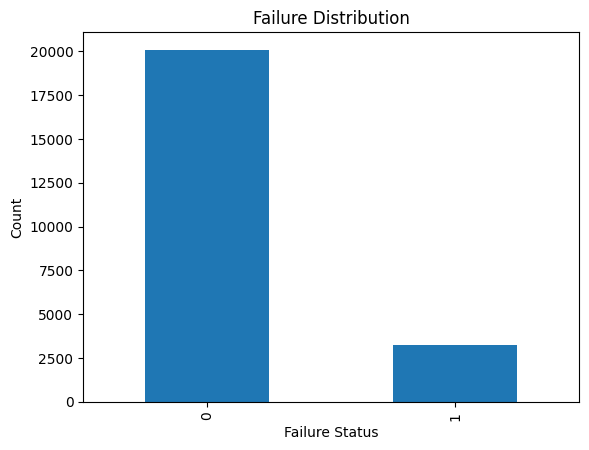

In [ ]:
import matplotlib.pyplot as plt

df['failure_within_24h'].value_counts().plot(
    kind='bar'
)

plt.title('Failure Distribution')
plt.xlabel('Failure Status')
plt.ylabel('Count')

plt.show()

In [ ]:
X = df.drop('failure_within_24h', axis=1)

y = df['failure_within_24h']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest using balanced data

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

# Train the model

model.fit(X_train, y_train)

# Generate predictions
# Predict probabilities

y_prob = model.predict_proba(X_test)[:,1]

# Custom threshold prediction

y_pred = (y_prob >=0.50).astype(int)

# Evaluate model performance

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print()

print(classification_report(
    y_test,
    y_pred
))

print()

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

Accuracy: 0.9736277873070326

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4019
           1       0.90      0.91      0.91       645

    accuracy                           0.97      4664
   macro avg       0.94      0.95      0.95      4664
weighted avg       0.97      0.97      0.97      4664


ROC-AUC: 0.9942791122015389


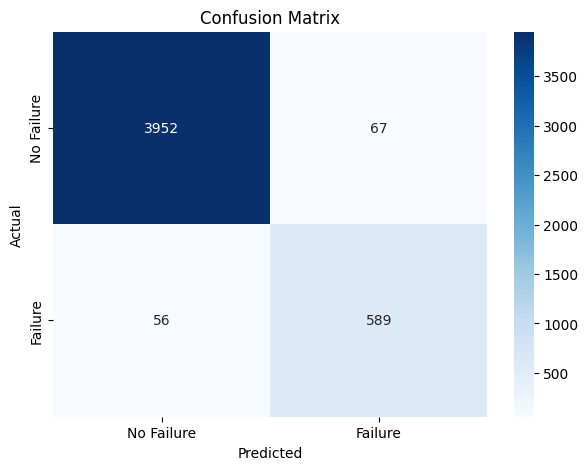

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Failure','Failure'],
    yticklabels=['No Failure','Failure']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [ ]:
print(X.columns.tolist())

['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp']


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

                   Feature  Importance
2        temperature_motor    0.277674
5                      rpm    0.228411
3        current_phase_avg    0.162474
1            vibration_rms    0.147536
4           pressure_level    0.070238
7  hours_since_maintenance    0.044705
6           operating_mode    0.031112
0             machine_type    0.024405
8             ambient_temp    0.013445


In [ ]:
joblib.dump(
    model,
    'failure_prediction_model.pkl'
)


['failure_prediction_model.pkl']

fast_api

In [ ]:
!pip install fastapi uvicorn pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("*******")

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)
print(public_url)

NgrokTunnel: "https://b0c8-34-106-86-79.ngrok-free.app" -> "http://localhost:8000"


In [ ]:

from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load("/content/failure_prediction_model.pkl")

@app.post("/predict")
def predict(data: dict):

    df = pd.DataFrame([data])

    prediction = int(model.predict(df)[0])

    return {
        "prediction": prediction
    }


In [ ]:

import nest_asyncio
import uvicorn
from threading import Thread

nest_asyncio.apply()

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

Thread(target=run).start()


In [ ]:

import requests

payload = {
    "machine_type": 1,
    "vibration_rms": 4.2,
    "temperature_motor": 78,
    "current_phase_avg": 12.5,
    "pressure_level": 101,
    "rpm": 1450,
    "operating_mode": 2,
    "hours_since_maintenance": 250,
    "ambient_temp": 32
}

response = requests.post(
    "https://edeb-136-65-231-56.ngrok-free.app/predict",
    json=payload
)

print(response.status_code)
print(response.text)


INFO:     Started server process [1679]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


404
<!DOCTYPE html>
<html class="h-full" lang="en-US" dir="ltr">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Regular-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-RegularItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Medium-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-MediumItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/ibm-plex-mono/IBMPlexMono-Text.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="prelo